# Online Retail Sales Analysis

This project analyzes an online retail dataset to understand customer purchasing behavior, sales trends, and product performance. The dataset contains transaction-level information such as invoice numbers, product descriptions, quantities, prices, customer IDs, and countries.

The objective of this analysis is to clean and explore the dataset, identify key sales insights, and perform customer segmentation using RFM (Recency, Frequency, Monetary) analysis. This helps in understanding customer value, identifying loyal customers, and detecting customers who are at risk of churn.

Through exploratory data analysis and visualization, this project highlights important business insights such as top-selling products, revenue trends over time, country-wise sales distribution, and customer segmentation patterns.

### Dataset Features
InvoiceNo – Unique invoice number  
StockCode – Product code  
Description – Product name  
Quantity – Number of items purchased  
InvoiceDate – Date of purchase  
UnitPrice – Price per unit  
CustomerID – Unique customer identifier  
Country – Customer location

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [2]:
df = pd.read_csv("online_retail.csv",encoding = 'ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


### Data Understanding

In [3]:
df.shape

(541909, 8)

In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.8 MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5268)

## Data Cleaning

In [9]:
# Adding an Extra Total_price Column showing total Purchase of a product as it will be very helpful in future for analysis 
df['TotalPrice'] = df['Quantity']*df['UnitPrice']

In [10]:
# Missing values were found in CustomerID and Description columns.  
# Since these fields are essential for customer and product level analysis,
# rows with missing values were removed from the dataset.

df = df.dropna(subset = ['Description','CustomerID']) 

In [11]:
# As duplicate Data can Distort whole datset so we are also deleting these value

df = df.drop_duplicates() 

In [12]:
# removing Negative values from the dataset

df = df[df['Quantity']>0]  

In [13]:
# converting invoice date into date column into appropriate data type as they help in analysis

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],dayfirst = True)
df['CustomerID'] = df['CustomerID'].astype('int')

In [14]:
## After Data cleaning we have 

print(df.shape)
print(df['UnitPrice'].min())
print(df['TotalPrice'].min())

(392732, 9)
0.0
0.0


In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  str           
 1   StockCode    392732 non-null  str           
 2   Description  392732 non-null  str           
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[us]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  int64         
 7   Country      392732 non-null  str           
 8   TotalPrice   392732 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 49.2 MB


### EDA

#### Top 10 Selling Products
We group products by description and calculate total quantity sold.


In [16]:
top_product = df.groupby('Description')['Quantity'].sum().sort_values(ascending = False).head(10)
top_product

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

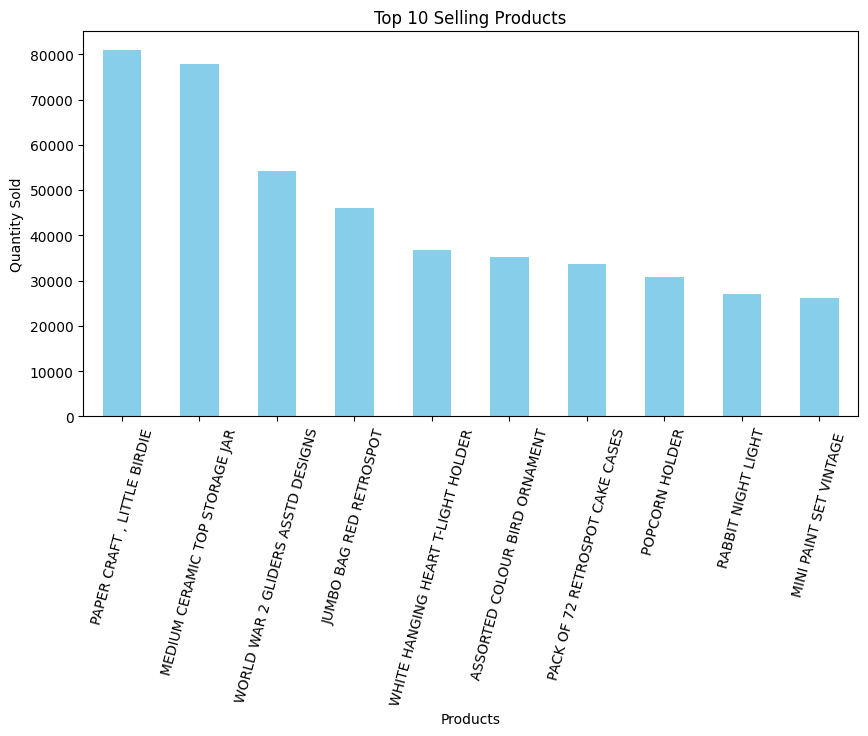

In [17]:
plt.figure(figsize=(10,5))
top_product.plot(kind='bar',color='skyblue')

plt.title("Top 10 Selling Products")
plt.xlabel("Products")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=75)
plt.show()

#### Top 10 Customers By Revenue
We group Customers by CustomerID and calculate total spend Amount.

In [18]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending = False).head(10)
top_customers

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalPrice, dtype: float64

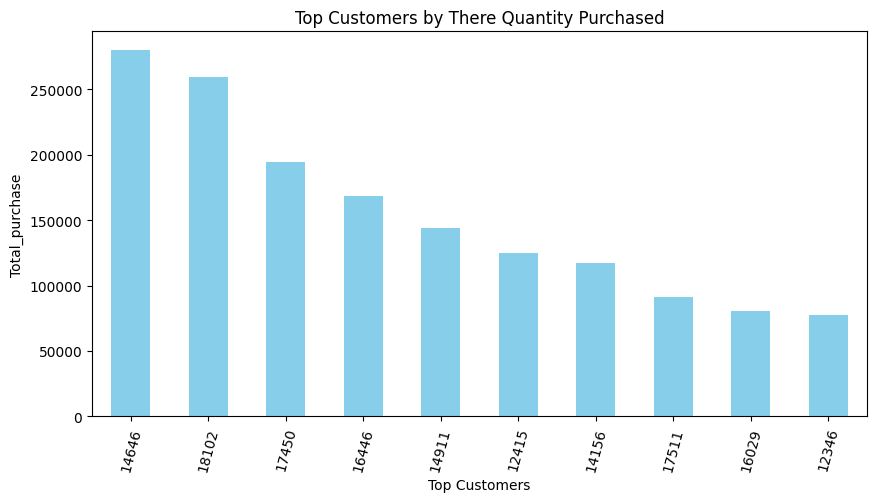

In [19]:
plt.figure(figsize=(10,5))
top_customers.plot(kind = 'bar',color = 'skyblue')
plt.title("Top Customers by There Quantity Purchased")
plt.xlabel("Top Customers")
plt.ylabel("Total_purchase")

plt.xticks(rotation=75)
plt.show()

#### Top Sales By Country


In [20]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending = False).head(10)
country_sales

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

#### Monthly Sales Revenue
Extracting knowledge about Months for Seasonal and Trend Analysis.

In [21]:
# Creating extra columns for time based Analysis

df['month']= df['InvoiceDate'].dt.month

In [22]:
monthly_sales = df.groupby('month')['TotalPrice'].sum()
monthly_sales

month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: TotalPrice, dtype: float64

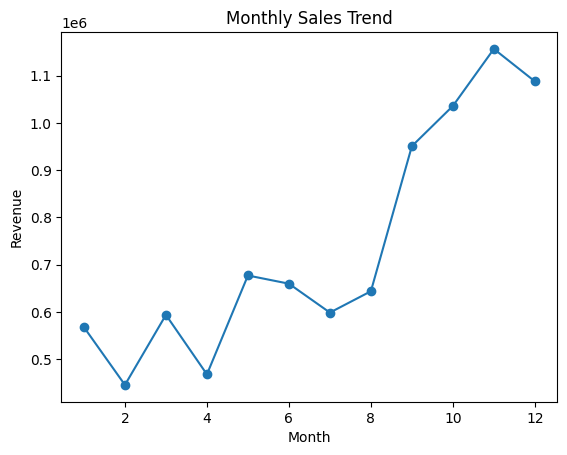

In [23]:
monthly_sales.plot(kind = 'line',marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

#### Revenue Contribution of Top 20% Customers

This analysis checks whether a small group of customers contributes a large share of total revenue (Pareto principle).

In [24]:
# Calculate total revenue generated by each customer
customer_revenue = df.groupby('CustomerID')['TotalPrice'].sum()

# Sort customers by revenue in descending order
customer_revenue = customer_revenue.sort_values(ascending=False)

# Select top 20% customers
top_20 = int(len(customer_revenue) * 0.2)
top_customers = customer_revenue.head(top_20)

# Calculate revenue contribution of top 20% customers
revenue_contribution = top_customers.sum() / customer_revenue.sum()

print("Revenue contribution of top 20% customers:", revenue_contribution)

Revenue contribution of top 20% customers: 0.7466062056310657


## RFM Analysis

RFM analysis is used to segment customers based on their purchasing behavior.

R – Recency: How recently a customer made a purchase  
F – Frequency: How often a customer purchases  
M – Monetary: How much money the customer spends

### Recency Calculation

Recency measures how many days have passed since the customer's last purchase.

In [25]:
# Define snapshot date (one day after last purchase in dataset)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate recency for each customer
recency = (snapshot_date - df.groupby('CustomerID')['InvoiceDate'].max()).dt.days

### Frequency Calculation

Frequency represents how many unique orders a customer has placed.

In [26]:
# Count unique invoices per customer
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

### Monetary Calculation

Monetary represents the total revenue generated by each customer.

In [27]:
# Calculate total spending by each customer
monetary = df.groupby('CustomerID')['TotalPrice'].sum()

### RFM Table

Combine Recency, Frequency, and Monetary values into a single table.

In [28]:
rfm = pd.concat([recency,frequency,monetary],axis = 1)
rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


### RFM Scoring

Customers are scored from 1 to 5 based on Recency, Frequency, and Monetary values.

In [29]:
# Lower recency = more recent purchase → higher score
rfm['R_score'] = pd.qcut(rfm['Recency'],5,labels = [5,4,3,2,1])

In [30]:
# Higher frequency means more purchases → higher score
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method = 'first'),5,labels = [1,2,3,4,5],duplicates = 'drop') 

In [31]:
# Higher spending customers receive higher score
rfm['M_score'] = pd.qcut(rfm['Monetary'],5,labels = [1,2,3,4,5])

### RFM Score Calculation
The final RFM score is created by combining Recency, Frequency, and Monetary scores.

In [32]:
rfm['RFM_score'] = rfm['R_score'].astype(str)+rfm['F_score'].astype(str)+rfm['M_score'].astype(str)

In [33]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,5,115
12347,2,7,4310.00,5,5,5,555
12348,75,4,1797.24,2,4,4,244
12349,19,1,1757.55,4,1,4,414
12350,310,1,334.40,1,1,2,112


In [34]:
rfm.info()

<class 'pandas.DataFrame'>
Index: 4339 entries, 12346 to 18287
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Recency    4339 non-null   int64   
 1   Frequency  4339 non-null   int64   
 2   Monetary   4339 non-null   float64 
 3   R_score    4339 non-null   category
 4   F_score    4339 non-null   category
 5   M_score    4339 non-null   category
 6   RFM_score  4339 non-null   str     
dtypes: category(3), float64(1), int64(2), str(1)
memory usage: 195.0 KB


### Customer Segmentation

In [35]:
# Convert RFM scores from categorical to integer for further analysis
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [36]:
# Convert Scores into Segments of Customers
rfm['Segment'] = 'Regular'
rfm.loc[(rfm['R_score'] <= 2) & (rfm['M_score'] <=2 ),'Segment'] = 'AT Risk'
rfm.loc[(rfm['R_score'] >= 4) & (rfm['M_score'] >= 4),'Segment'] = 'Loyal'
rfm.loc[(rfm['R_score'] == 5) & (rfm['F_score'] == 5) & (rfm['M_score'] == 5),'Segment'] = 'VIP'

In [37]:
rfm.sample(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
CustomerID,,,,,,,,
13265,53,5,2092.66,3,4,5,345,Regular
13803,255,1,277.07,1,1,2,112,AT Risk
14703,15,1,318.17,4,1,2,412,Regular
13372,90,1,378.64,2,1,2,212,AT Risk
12576,36,5,1315.83,3,4,4,344,Regular
15118,134,1,244.80,2,1,1,211,AT Risk
16258,45,5,5203.51,3,4,5,345,Regular
18270,38,2,283.15,3,3,2,332,Regular
12792,257,1,400.54,1,1,2,112,AT Risk


In [38]:
rfm['Segment'].value_counts()

Segment
Regular    2252
AT Risk    1011
Loyal       729
VIP         347
Name: count, dtype: int64

## Visualizations

### RFM Correlation Analysis

A correlation heatmap is used to examine the relationships between Recency, Frequency, and Monetary values.

• A negative correlation between Recency and Frequency indicates that customers who purchased recently tend to buy more frequently.

• A positive correlation between Frequency and Monetary suggests that customers who buy more often tend to spend more.

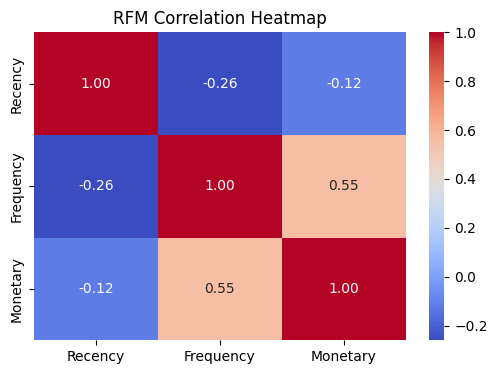

In [39]:
plt.figure(figsize=(6,4))

sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("RFM Correlation Heatmap")

plt.show()

### Customer Segmentation Distribution

This visualization shows the distribution of customers across different RFM segments.

The segmentation helps identify high-value customers, loyal buyers, and customers who may be at risk of churn.

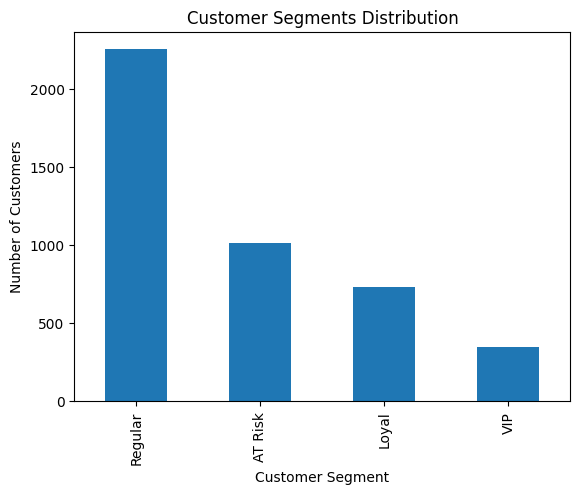

In [40]:
rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segments Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

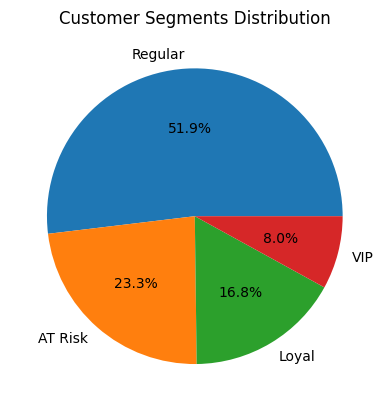

In [41]:
rfm['Segment'].value_counts().plot(kind='pie',label = True,autopct = '%1.1f%%')
plt.title("Customer Segments Distribution")
plt.show()

### Revenue Contribution by Customer Segment

This visualization shows the total revenue generated by each customer segment identified through RFM analysis.

It helps identify which customer groups contribute the most to overall business revenue.

In [42]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()
segment_revenue

Segment
AT Risk     246204.451
Loyal      2254470.270
Regular    2489843.033
VIP        3896691.140
Name: Monetary, dtype: float64

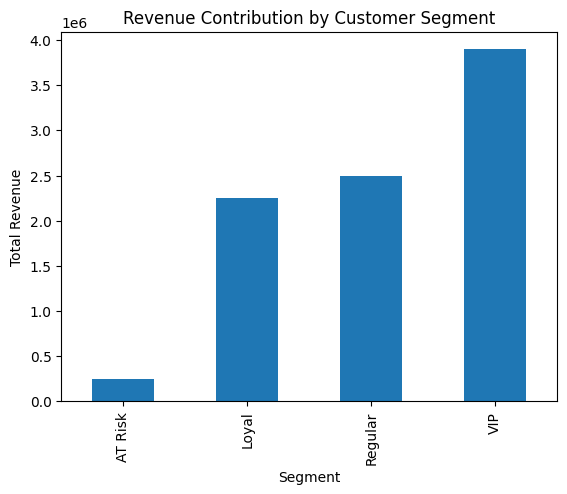

In [43]:
segment_revenue.plot(kind='bar')

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.show()

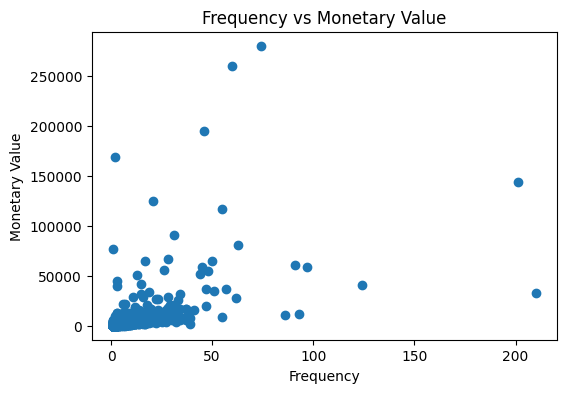

In [44]:
plt.figure(figsize=(6,4))

plt.scatter(rfm['Frequency'], rfm['Monetary'])

plt.title("Frequency vs Monetary Value")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")

plt.show()

## Key Business Insights
#### Sales Seasonality
Sales trend analysis reveals that November is the peak sales month. This indicates strong seasonal demand, likely influenced by holiday shopping and promotional events such as Black Friday and the Christmas shopping season.

#### Geographic Sales Distribution
The United Kingdom contributes the highest share of total revenue, suggesting that the majority of transactions originate from this region. This indicates that the business has its strongest market presence in the UK.

#### Top Selling Product
The product “PAPER CRAFT , LITTLE BIRDIE” is identified as the most frequently purchased item in the dataset. This suggests high demand for craft-related or decorative products among customers.

#### Customer Revenue Concentration
Analysis shows that approximately 75% of total revenue is generated by the top 20% of customers. This demonstrates the Pareto Principle (80/20 rule), where a small portion of customers contributes the majority of the revenue.

#### Customer Segmentation using RFM Analysis
Customers were segmented using Recency, Frequency, and Monetary (RFM) analysis, which groups customers based on their purchasing behavior. This segmentation helps businesses better understand customer engagement and value.

Customer segments identified include:
VIP Customers
Loyal Customers
Regular Customers
At Risk Customers

#### High Value Customers (VIP Segment)
The VIP customer segment generates the highest revenue, despite representing a smaller portion of the overall customer base. These customers are high spenders and frequent buyers, making them extremely valuable for the business.
Businesses should prioritize retaining these customers through loyalty programs, exclusive offers, and personalized marketing.

#### Regular Customers
The majority of customers fall into the Regular segment, indicating that many customers make occasional purchases but are not highly engaged with the business. These customers represent an opportunity for conversion into loyal buyers through targeted promotions and personalized recommendations.

#### At Risk Customers
A portion of customers were identified as At Risk, meaning they have not made recent purchases and show lower engagement levels. These customers may require re-engagement strategies such as discounts, reminder emails, or special promotions to encourage repeat purchases.

### Business Recommendations

#### Based on the analysis, the following strategies can help improve business performance:


Focus on retaining high-value VIP customers through loyalty programs and exclusive benefits.

Implement targeted marketing campaigns to convert Regular customers into Loyal customers.

Develop re-engagement strategies for At Risk customers to reduce potential churn.

Increase marketing and inventory planning during high-demand months such as November.

## Conclusion

- This project analyzed an online retail dataset to understand sales trends and customer purchasing behavior.
- Data cleaning and exploratory data analysis were performed to identify patterns and anomalies in the dataset.
- The analysis revealed that **November is the peak sales month**, indicating strong seasonal demand.
- The **United Kingdom generates the highest revenue**, showing that most business activity is concentrated in this region.
- Product analysis identified **“PAPER CRAFT, LITTLE BIRDIE”** as the most frequently purchased item.
- Customer behavior was analyzed using **RFM (Recency, Frequency, Monetary) segmentation**.
- Customers were segmented into **VIP, Loyal, Regular, and At Risk** categories.
- The analysis showed that **VIP customers contribute the highest share of total revenue**.
- A portion of customers were identified as **At Risk**, indicating potential churn.
- Businesses can use these insights to improve **customer retention, targeted marketing, and revenue growth strategies**.